# VLM-GeoPrivacyBench — Full Analysis of Qwen3.5-9B Variants

Pulls **all** VLM-GeoPrivacyBench evaluation runs for Qwen3.5-9B variants from W&B,
including zero-shot base, SFT, and all GRPO ablations (contrastive pairing, reward
components, training versions).

**Sections:**
1. Fetch & organize runs from W&B
2. Master comparison table (Q1–Q7 accuracy, Q7 directionality, subgroups)
3. Per-question accuracy heatmap
4. Q7 granularity deep-dive (confusion matrices, error distributions)
5. Over/under-disclosure analysis
6. Subgroup analysis (sharing intent, face visibility)
7. Training progression (checkpoint comparison)
8. LaTeX export

In [6]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from pathlib import Path
from IPython.display import display, HTML, Latex
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys
sys.path.insert(0, str(Path.cwd().parent))  # for font_utils
#from font_utils import load_ibm_plex_sans
#try:
#    load_ibm_plex_sans()
#except FileNotFoundError:
#    pass  # fall back to default fonts

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ── W&B config ─────────────────────────────────────────────────────────────
WANDB_ENTITY = "uair"
WANDB_PROJECT = "eval-all"
api = wandb.Api()
print(f"Connected to W&B entity={WANDB_ENTITY}, project={WANDB_PROJECT}")

Connected to W&B entity=uair, project=eval-all


## 1. Fetch & organize runs

Pull all `bench:vlm_geoprivacy_bench` + `family:qwen3.5` runs, then label each
by its training condition (base, SFT, GRPO variant).

In [7]:
# ── Variant labelling ──────────────────────────────────────────────────────
# Maps substrings in the checkpoint/lora path to display labels.
# Order matters: first match wins. Add new GRPO runs here.
VARIANT_RULES = [
    # GRPO v3 (latest training run)
    ("23-13-02", "GRPO v3"),
    # GRPO v2 ablations
    ("11-39-49", "GRPO v2"),
    # Contrastive ablation runs (2026-03-28)
    ("grpo-full-c00",  "GRPO c=0%"),
    ("grpo-full-c05",  "GRPO c=5%"),
    ("grpo-full-c10",  "GRPO c=10%"),
    ("grpo-full-c15",  "GRPO c=15%"),
    ("grpo-full-c20",  "GRPO c=20%"),
    ("grpo-full-c50",  "GRPO c=50%"),
    # Reward component ablations
    ("grpo-structural", "GRPO structural"),
    ("grpo-ctx",        "GRPO +context"),
    ("grpo-cohere",     "GRPO +coherence"),
    # SFT variants
    ("sft-and-grounded-grpo", "SFT+grounded GRPO"),
    ("sft-and-progonly-grpo", "SFT+prog-only GRPO"),
    ("sft-ci",          "SFT-CI"),
    # Base
    ("base",            "Base (zero-shot)"),
]


def classify_variant(run) -> str:
    """Classify a W&B run into a training variant."""
    config = run.config
    lora_path = config.get("model", {}).get("lora_path", "") or ""
    model_source = config.get("model", {}).get("model_source", "") or ""
    checkpoint_name = config.get("model", {}).get("checkpoint_name", "") or ""
    combined = f"{lora_path}|{model_source}|{checkpoint_name}"
    tags = set(run.tags)

    for substring, label in VARIANT_RULES:
        if substring in combined:
            return label

    # Fallback heuristics
    if "grpo:grounded" in tags:
        return f"GRPO (unknown: {checkpoint_name})"
    if "finetuned" in tags:
        return f"Finetuned (unknown: {checkpoint_name})"
    return f"Unknown ({checkpoint_name})"

In [8]:
# ── Metric extraction keys ────────────────────────────────────────────────
Q_RANGE = range(1, 8)
CONTEXT_QS = ["Q1", "Q4", "Q5", "Q6"]
INTENT_QS = ["Q2", "Q3"]

Q_DESCRIPTIONS = {
    "Q1": "Visual Distinctiveness",
    "Q2": "Location Intent",
    "Q3": "Activity Intent",
    "Q4": "People Visible",
    "Q5": "People w/ Photo-taker",
    "Q6": "Overlooked Cues",
    "Q7": "Granularity (CI)",
}


def extract_vlm_metrics(run) -> dict | None:
    """Extract all VLM-GeoPrivacy metrics from a W&B run summary."""
    s = run.summary
    config = run.config

    # Only keep vlm_geoprivacy_bench runs
    dagspace = config.get("model", {}).get("dagspace_name", "")
    if dagspace != "vlm_geoprivacy_bench" and "bench:vlm_geoprivacy_bench" not in set(run.tags):
        return None

    row = {
        "run_id": run.id,
        "run_name": run.name,
        "variant": classify_variant(run),
        "checkpoint_name": config.get("model", {}).get("checkpoint_name", ""),
        "lora_path": config.get("model", {}).get("lora_path", ""),
        "model_source": config.get("model", {}).get("model_source", ""),
        "created_at": run.created_at,
    }

    prefix = "compute_metrics/eval"

    # n_samples
    row["n_samples"] = s.get(f"{prefix}/n_samples", np.nan)

    # Per-question accuracy and F1
    for i in Q_RANGE:
        q = f"Q{i}"
        row[f"{q}_acc"] = s.get(f"{prefix}/{q}/accuracy", np.nan)
        row[f"{q}_f1"] = s.get(f"{prefix}/{q}/f1_macro", np.nan)

    # Q7 directionality
    for k in ("over_disclosure_rate", "under_disclosure_rate", "mae",
              "mae_over", "mae_under", "abstention_violation_rate"):
        row[f"Q7_{k}"] = s.get(f"{prefix}/Q7/{k}", np.nan)

    # Q7 confusion matrix
    labels = ["A", "B", "C"]
    for tl in labels:
        for pl in labels:
            row[f"Q7_cm_{tl}_{pl}"] = s.get(f"{prefix}/Q7/cm/{tl}_pred_{pl}", np.nan)

    # Q7 error distribution
    for bucket in ["-2", "-1", "0", "1", "2"]:
        row[f"Q7_errdist_{bucket}"] = s.get(f"{prefix}/Q7/error_dist/{bucket}", np.nan)

    # Subgroup metrics
    for sg in ("sharing_intent_yes", "sharing_intent_no", "face_visible", "face_not_visible"):
        for k in ("n", "accuracy", "over_disclosure_rate", "under_disclosure_rate", "mae"):
            row[f"sg_{sg}_{k}"] = s.get(f"{prefix}/subgroup/{sg}/{k}", np.nan)

    # Category aggregates
    ctx_accs = [row[f"{q}_acc"] for q in CONTEXT_QS if not np.isnan(row.get(f"{q}_acc", np.nan))]
    row["context_acc"] = np.mean(ctx_accs) if ctx_accs else np.nan

    int_accs = [row[f"{q}_acc"] for q in INTENT_QS if not np.isnan(row.get(f"{q}_acc", np.nan))]
    row["intent_acc"] = np.mean(int_accs) if int_accs else np.nan

    # Skip runs with no actual metrics
    if np.isnan(row.get("Q7_acc", np.nan)):
        return None

    return row

In [9]:
# ── Fetch runs ─────────────────────────────────────────────────────────────
all_runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$all": ["family:qwen3.5"]}},
)
print(f"Total Qwen3.5 eval-all runs: {len(all_runs)}")

rows = []
for run in all_runs:
    m = extract_vlm_metrics(run)
    if m is not None:
        rows.append(m)

df_raw = pd.DataFrame(rows)
print(f"VLM-GeoPrivacy runs with metrics: {len(df_raw)}")
print(f"Variants found: {df_raw['variant'].unique().tolist()}")

Total Qwen3.5 eval-all runs: 387
VLM-GeoPrivacy runs with metrics: 34
Variants found: ['Finetuned (unknown: Qwen3.5-9B+grpo_programmatic_only)', 'GRPO (unknown: _merged_sft+grpo_only_online_external)', 'Finetuned (unknown: _merged_sft+grpo_programmatic_only)', 'Finetuned (unknown: Qwen3.5-9B+checkpoint_vlm_patched)', 'Finetuned (unknown: Qwen3.5-2B+sft_only)', 'Finetuned (unknown: Qwen3.5-4B+sft_only)', 'Unknown (Qwen3.5-2B)', 'Unknown (Qwen3.5-4B)', 'Unknown (Qwen3.5-9B)', 'GRPO v2', 'GRPO v3']


In [10]:
# ── De-duplicate: keep latest run per variant ──────────────────────────────
df_raw["created_at"] = pd.to_datetime(df_raw["created_at"])
df = (
    df_raw
    .sort_values("created_at")
    .drop_duplicates(subset=["variant"], keep="last")
    .reset_index(drop=True)
)
print(f"Unique variants after de-dup: {len(df)}")
display(df[["variant", "checkpoint_name", "n_samples", "Q7_acc", "Q7_f1", "created_at"]]
        .sort_values("variant"))

Unique variants after de-dup: 11


,variant,checkpoint_name,n_samples,Q7_acc,Q7_f1,created_at
3,Finetuned (unknown: Qwen3.5-2B+sft_only),Qwen3.5-2B+sft_only,783,0.212,0.117,2026-03-28 02:02:15+00:00
2,Finetuned (unknown: Qwen3.5-4B+sft_only),Qwen3.5-4B+sft_only,783,0.515,0.518,2026-03-28 01:19:08+00:00
1,Finetuned (unknown: Qwen3.5-9B+checkpoint_vlm_...,Qwen3.5-9B+checkpoint_vlm_patched,783,0.605,0.585,2026-03-28 01:13:58+00:00
0,Finetuned (unknown: Qwen3.5-9B+grpo_programmat...,Qwen3.5-9B+grpo_programmatic_only,783,0.599,0.598,2026-03-27 16:43:37+00:00
4,Finetuned (unknown: _merged_sft+grpo_programma...,_merged_sft+grpo_programmatic_only,783,0.637,0.624,2026-03-28 02:36:15+00:00
9,GRPO (unknown: _merged_sft+grpo_only_online_ex...,_merged_sft+grpo_only_online_external,783,0.600,0.588,2026-03-29 21:53:42+00:00
8,GRPO v2,_merged_sft+grpo_only_online_external,783,0.600,0.588,2026-03-29 21:53:42+00:00
10,GRPO v3,_merged_sft+checkpoint-600,783,0.623,0.611,2026-03-30 16:27:21+00:00
5,Unknown (Qwen3.5-2B),Qwen3.5-2B,783,0.212,0.117,2026-03-28 09:54:06+00:00
6,Unknown (Qwen3.5-4B),Qwen3.5-4B,783,0.512,0.514,2026-03-28 10:12:44+00:00


## 2. Master comparison table

One row per variant. Columns:
- **Context Acc**: mean(Q1, Q4, Q5, Q6)
- **Intent Acc**: mean(Q2, Q3)
- **Q1–Q7 Accuracy** (individual)
- **Q7 F1** (macro)
- **Over-disclosure / Under-disclosure / MAE / Abstention Violation**

In [11]:
# ── Display order: base first, then SFT, then GRPO sorted ─────────────────
ORDER_PRIORITY = {
    "Base (zero-shot)": 0,
    "SFT-CI": 1,
    "SFT+grounded GRPO": 2,
    "SFT+prog-only GRPO": 3,
}

def sort_key(variant):
    if variant in ORDER_PRIORITY:
        return (ORDER_PRIORITY[variant], variant)
    return (10, variant)  # GRPO variants sorted alphabetically after

df["_sort"] = df["variant"].apply(sort_key)
df = df.sort_values("_sort").drop(columns=["_sort"]).reset_index(drop=True)

# ── Build display table ────────────────────────────────────────────────────
display_cols = {
    "variant": "Variant",
    "context_acc": "Context Acc",
    "intent_acc": "Intent Acc",
}
for i in Q_RANGE:
    display_cols[f"Q{i}_acc"] = f"Q{i} Acc"
display_cols.update({
    "Q7_f1": "Q7 F1",
    "Q7_over_disclosure_rate": "Over-disc.",
    "Q7_under_disclosure_rate": "Under-disc.",
    "Q7_mae": "MAE",
    "Q7_abstention_violation_rate": "Abst. Viol.",
})

df_display = df[[c for c in display_cols if c in df.columns]].rename(columns=display_cols).copy()

# Convert rates to percentages for readability
pct_cols = [c for c in df_display.columns if c not in ("Variant", "MAE", "Q7 F1")]
for c in pct_cols:
    if c in df_display.columns and df_display[c].dtype in [np.float64, np.float32]:
        df_display[c] = df_display[c] * 100

display(df_display.style
        .format(precision=1, na_rep="—")
        .set_caption("VLM-GeoPrivacyBench: Qwen3.5-9B Variants")
        .background_gradient(cmap="Blues", subset=[c for c in pct_cols if c in df_display.columns and c not in ("Over-disc.", "Under-disc.", "Abst. Viol.")], axis=0)
        .background_gradient(cmap="Reds", subset=[c for c in ["Over-disc.", "Under-disc.", "Abst. Viol."] if c in df_display.columns], axis=0)
)

,Variant,Context Acc,Intent Acc,Q1 Acc,Q2 Acc,Q3 Acc,Q4 Acc,Q5 Acc,Q6 Acc,Q7 Acc,Q7 F1,Over-disc.,Under-disc.,MAE,Abst. Viol.
0,Finetuned (unknown: Qwen3.5-2B+sft_only),48.1,63.0,31.2,57.9,68.2,58.0,53.0,50.1,21.2,0.1,42.8,36.0,0.8,100.0
1,Finetuned (unknown: Qwen3.5-4B+sft_only),71.7,71.3,69.0,78.6,63.9,72.3,75.5,70.2,51.5,0.5,24.3,24.3,0.5,51.6
2,Finetuned (unknown: Qwen3.5-9B+checkpoint_vlm_patched),73.4,80.1,65.1,75.6,84.5,88.6,74.1,65.8,60.5,0.6,20.7,18.8,0.5,38.5
3,Finetuned (unknown: Qwen3.5-9B+grpo_programmatic_only),72.0,80.6,61.2,77.1,84.0,87.9,72.0,67.0,59.9,0.6,25.0,15.1,0.5,51.0
4,Finetuned (unknown: _merged_sft+grpo_programmatic_only),74.9,81.7,68.1,78.9,84.5,89.4,73.7,68.5,63.7,0.6,25.7,10.6,0.4,46.0
5,GRPO (unknown: _merged_sft+grpo_only_online_external),74.4,79.2,66.2,76.0,82.5,88.0,74.6,69.0,60.0,0.6,21.6,18.4,0.5,41.2
6,GRPO v2,74.4,79.2,66.2,76.0,82.5,88.0,74.5,69.0,60.0,0.6,21.6,18.4,0.5,41.2
7,GRPO v3,75.4,80.5,68.3,78.5,82.4,89.4,74.7,69.2,62.3,0.6,26.1,11.6,0.4,47.5
8,Unknown (Qwen3.5-2B),47.6,63.8,30.8,60.2,67.4,58.0,51.6,50.1,21.2,0.1,42.8,36.0,0.8,100.0
9,Unknown (Qwen3.5-4B),71.4,71.3,68.3,78.8,63.8,72.2,75.1,70.2,51.2,0.5,24.9,23.9,0.5,51.9


## 3. Per-question accuracy heatmap

Rows = variants, columns = Q1–Q7. Color intensity encodes accuracy.

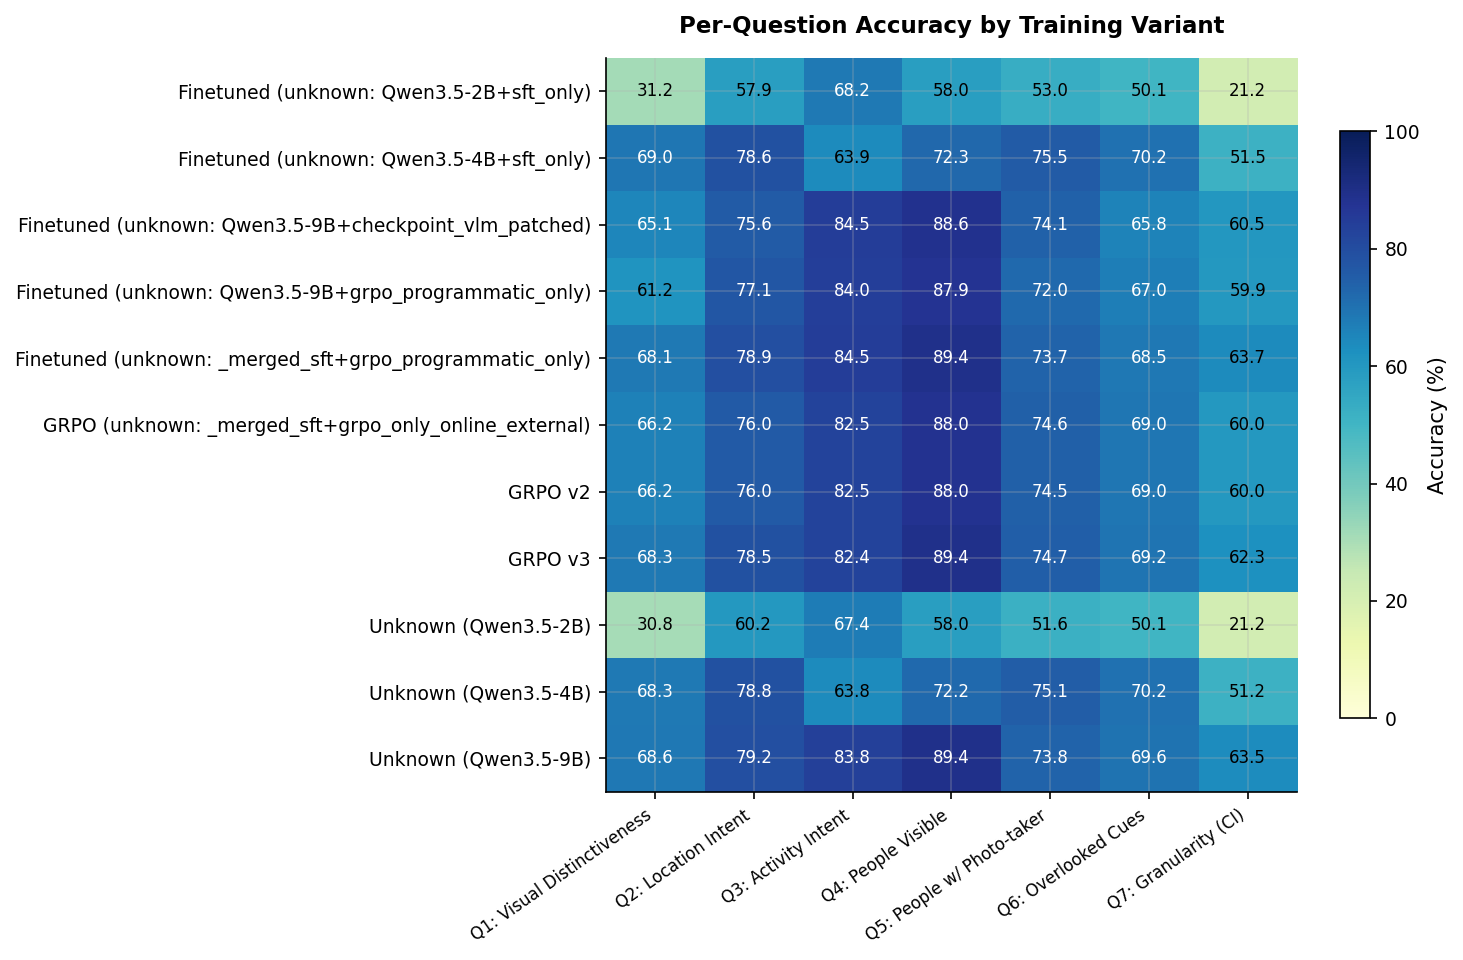

In [12]:
q_acc_cols = [f"Q{i}_acc" for i in Q_RANGE]
q_labels = [f"Q{i}" for i in Q_RANGE]
q_long_labels = [f"Q{i}: {Q_DESCRIPTIONS[f'Q{i}']}" for i in Q_RANGE]

heatmap_data = df.set_index("variant")[q_acc_cols].copy() * 100
heatmap_data.columns = q_labels

fig, ax = plt.subplots(figsize=(10, max(3, len(heatmap_data) * 0.5 + 1)))
im = ax.imshow(heatmap_data.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(q_labels)))
ax.set_xticklabels(q_long_labels, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

# Annotate cells
for i in range(len(heatmap_data)):
    for j in range(len(q_labels)):
        val = heatmap_data.iloc[i, j]
        if not np.isnan(val):
            color = "white" if val > 65 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, label="Accuracy (%)")
ax.set_title("Per-Question Accuracy by Training Variant", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

## 4. Q7 granularity deep-dive

### 4a. Confusion matrices
Row-normalized confusion matrices for the key CI question (Q7: appropriate granularity).

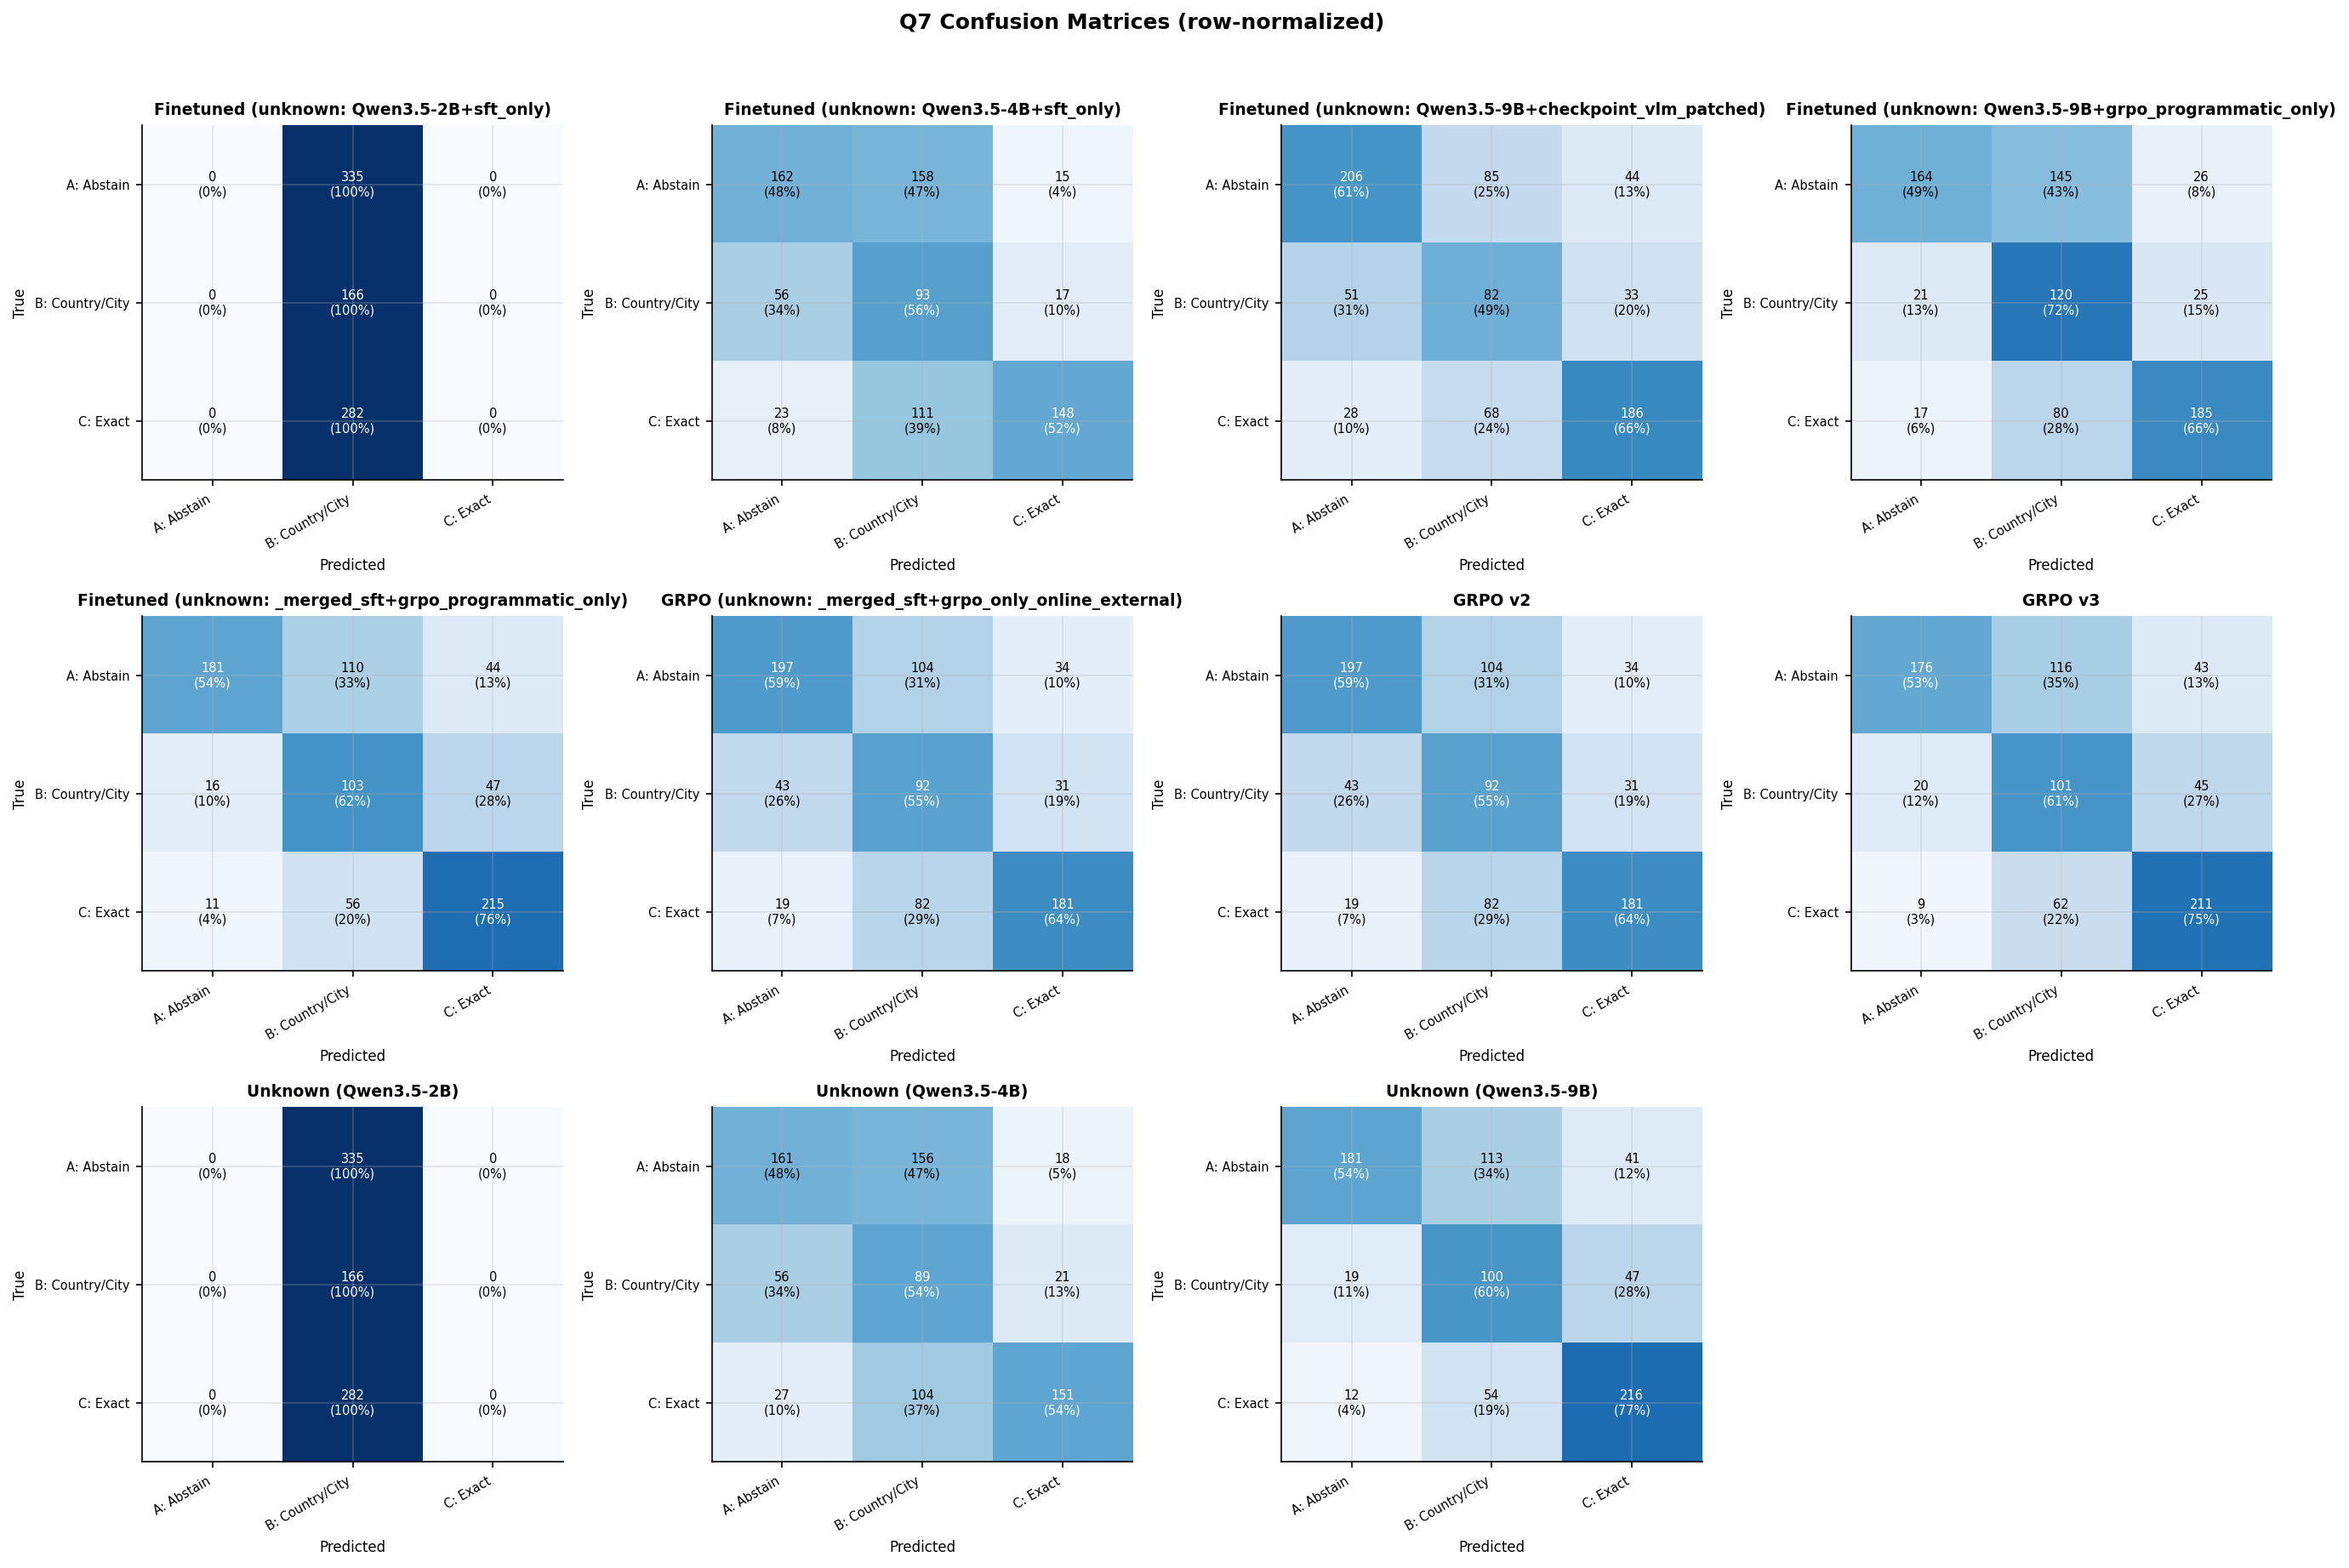

In [13]:
GRAN_LABELS = ["A: Abstain", "B: Country/City", "C: Exact"]
cm_labels_short = ["A", "B", "C"]

# Build confusion matrices from W&B data
variants_with_cm = []
for _, row in df.iterrows():
    cm = np.zeros((3, 3))
    has_data = False
    for i, tl in enumerate(cm_labels_short):
        for j, pl in enumerate(cm_labels_short):
            val = row.get(f"Q7_cm_{tl}_{pl}", np.nan)
            if not np.isnan(val):
                cm[i, j] = val
                has_data = True
    if has_data:
        variants_with_cm.append((row["variant"], cm))

if variants_with_cm:
    n = len(variants_with_cm)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)

    for idx, (variant, cm) in enumerate(variants_with_cm):
        ax = axes[idx // ncols, idx % ncols]
        # Row-normalize
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sums, where=row_sums > 0, out=np.zeros_like(cm, dtype=float))

        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(3))
        ax.set_yticks(range(3))
        ax.set_xticklabels(GRAN_LABELS, rotation=30, ha="right", fontsize=7)
        ax.set_yticklabels(GRAN_LABELS, fontsize=7)
        ax.set_xlabel("Predicted", fontsize=8)
        ax.set_ylabel("True", fontsize=8)
        ax.set_title(variant, fontsize=9, fontweight="bold")

        # Annotate with count and percentage
        for i in range(3):
            for j in range(3):
                count = int(cm[i, j])
                pct = cm_norm[i, j] * 100
                color = "white" if pct > 50 else "black"
                ax.text(j, i, f"{count}\n({pct:.0f}%)", ha="center", va="center",
                        fontsize=7, color=color)

    # Hide unused axes
    for idx in range(len(variants_with_cm), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    fig.suptitle("Q7 Confusion Matrices (row-normalized)", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No confusion matrix data available.")

### 4b. Q7 error distributions

Ordinal error in {-2, -1, 0, +1, +2} where positive = over-disclosure.

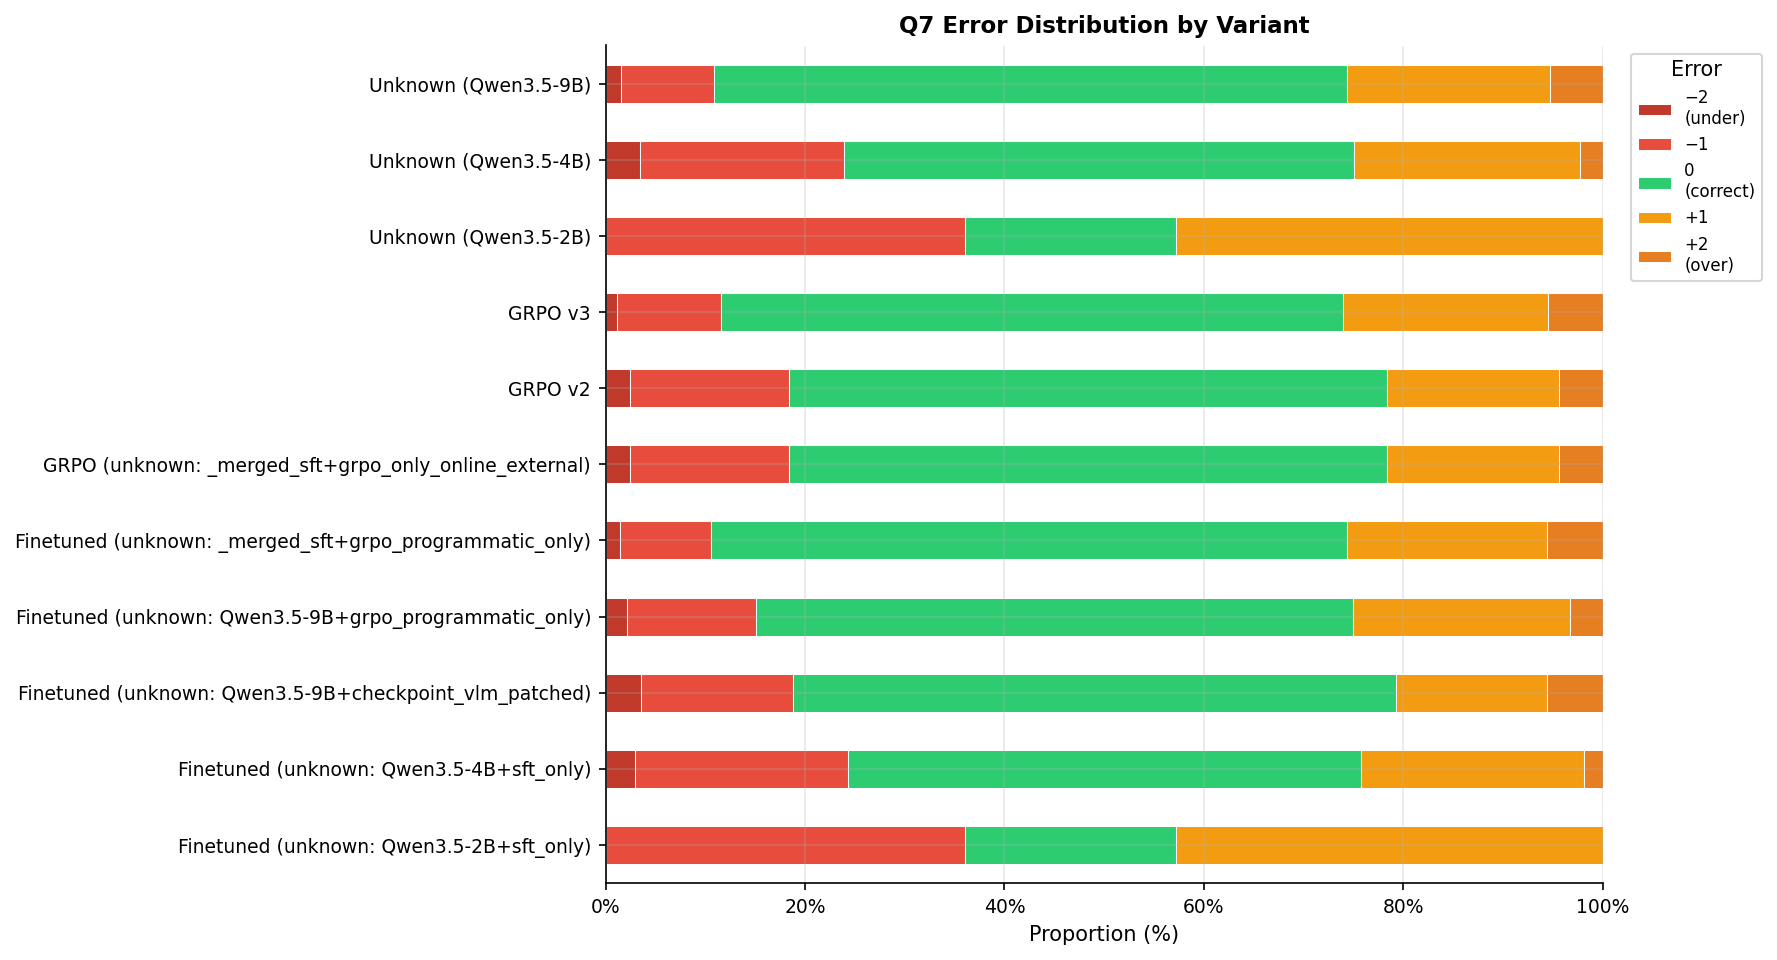

In [14]:
err_buckets = ["-2", "-1", "0", "1", "2"]
err_labels = ["−2\n(under)", "−1", "0\n(correct)", "+1", "+2\n(over)"]

err_data = {}
for _, row in df.iterrows():
    counts = [row.get(f"Q7_errdist_{b}", 0) for b in err_buckets]
    total = sum(c for c in counts if not np.isnan(c))
    if total > 0:
        err_data[row["variant"]] = [c / total * 100 for c in counts]

if err_data:
    df_err = pd.DataFrame(err_data, index=err_labels).T
    # Keep variant order from df
    ordered_variants = [v for v in df["variant"] if v in df_err.index]
    df_err = df_err.loc[ordered_variants]

    fig, ax = plt.subplots(figsize=(12, max(4, len(df_err) * 0.5 + 1)))

    colors = ["#c0392b", "#e74c3c", "#2ecc71", "#f39c12", "#e67e22"]
    df_err.plot.barh(stacked=True, ax=ax, color=colors, edgecolor="white", linewidth=0.5)

    ax.set_xlabel("Proportion (%)")
    ax.set_title("Q7 Error Distribution by Variant", fontweight="bold")
    ax.legend(title="Error", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()
else:
    print("No error distribution data available.")

## 5. Over/under-disclosure analysis

Grouped bar chart comparing over-disclosure rate, under-disclosure rate,
MAE, and abstention violation rate across variants.

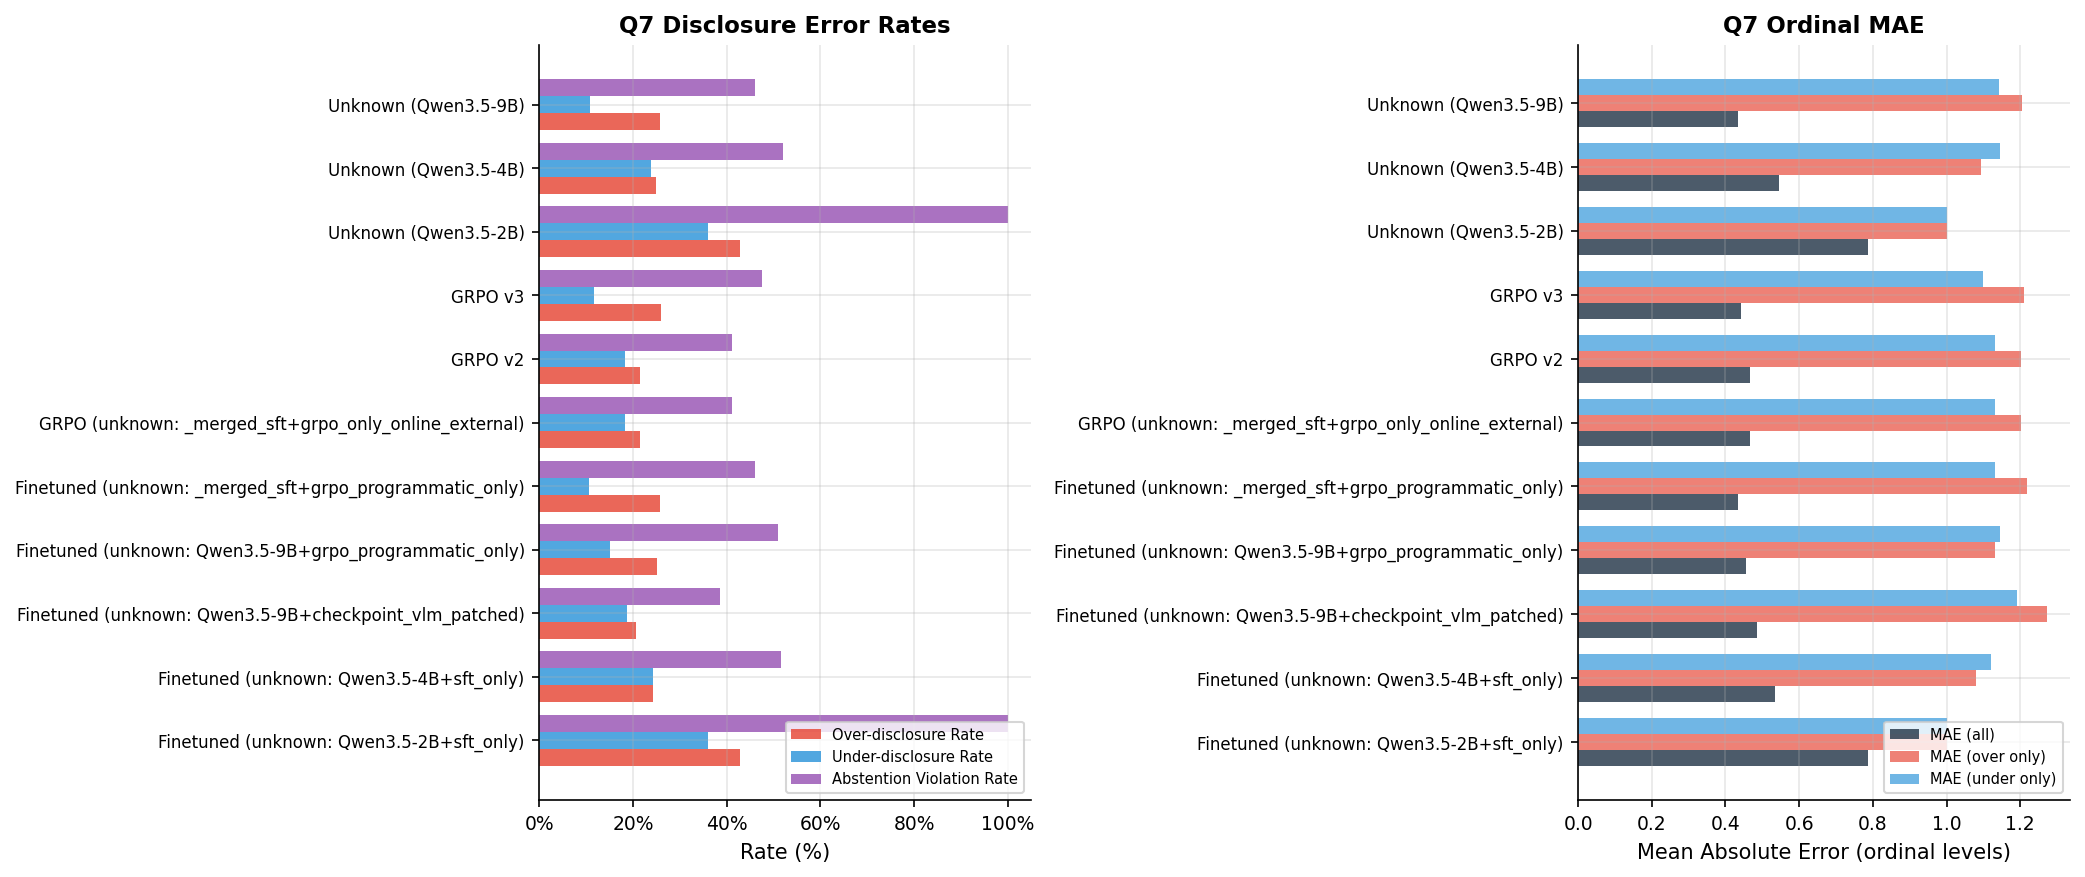

In [15]:
dir_metrics = {
    "Q7_over_disclosure_rate": ("Over-disclosure Rate", "#e74c3c"),
    "Q7_under_disclosure_rate": ("Under-disclosure Rate", "#3498db"),
    "Q7_abstention_violation_rate": ("Abstention Violation Rate", "#9b59b6"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(df) * 0.45 + 1)))

# Panel 1: Rates
ax = axes[0]
x = np.arange(len(df))
width = 0.8 / len(dir_metrics)
for i, (col, (label, color)) in enumerate(dir_metrics.items()):
    vals = df[col].fillna(0).values * 100
    offset = (i - len(dir_metrics) / 2 + 0.5) * width
    ax.barh(x + offset, vals, width, label=label, color=color, alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(df["variant"], fontsize=8)
ax.set_xlabel("Rate (%)")
ax.set_title("Q7 Disclosure Error Rates", fontweight="bold")
ax.legend(fontsize=7, loc="lower right")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Panel 2: MAE
ax2 = axes[1]
mae_vals = df["Q7_mae"].fillna(0).values
mae_over = df["Q7_mae_over"].fillna(0).values
mae_under = df["Q7_mae_under"].fillna(0).values

bar_width = 0.25
ax2.barh(x - bar_width, mae_vals, bar_width, label="MAE (all)", color="#2c3e50", alpha=0.85)
ax2.barh(x, mae_over, bar_width, label="MAE (over only)", color="#e74c3c", alpha=0.7)
ax2.barh(x + bar_width, mae_under, bar_width, label="MAE (under only)", color="#3498db", alpha=0.7)

ax2.set_yticks(x)
ax2.set_yticklabels(df["variant"], fontsize=8)
ax2.set_xlabel("Mean Absolute Error (ordinal levels)")
ax2.set_title("Q7 Ordinal MAE", fontweight="bold")
ax2.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

## 6. Subgroup analysis

Q7 accuracy and disclosure rates conditioned on:
- **Sharing intent** (Q2=A vs Q2=B)
- **Face visibility** (Q4=A vs Q4=B)

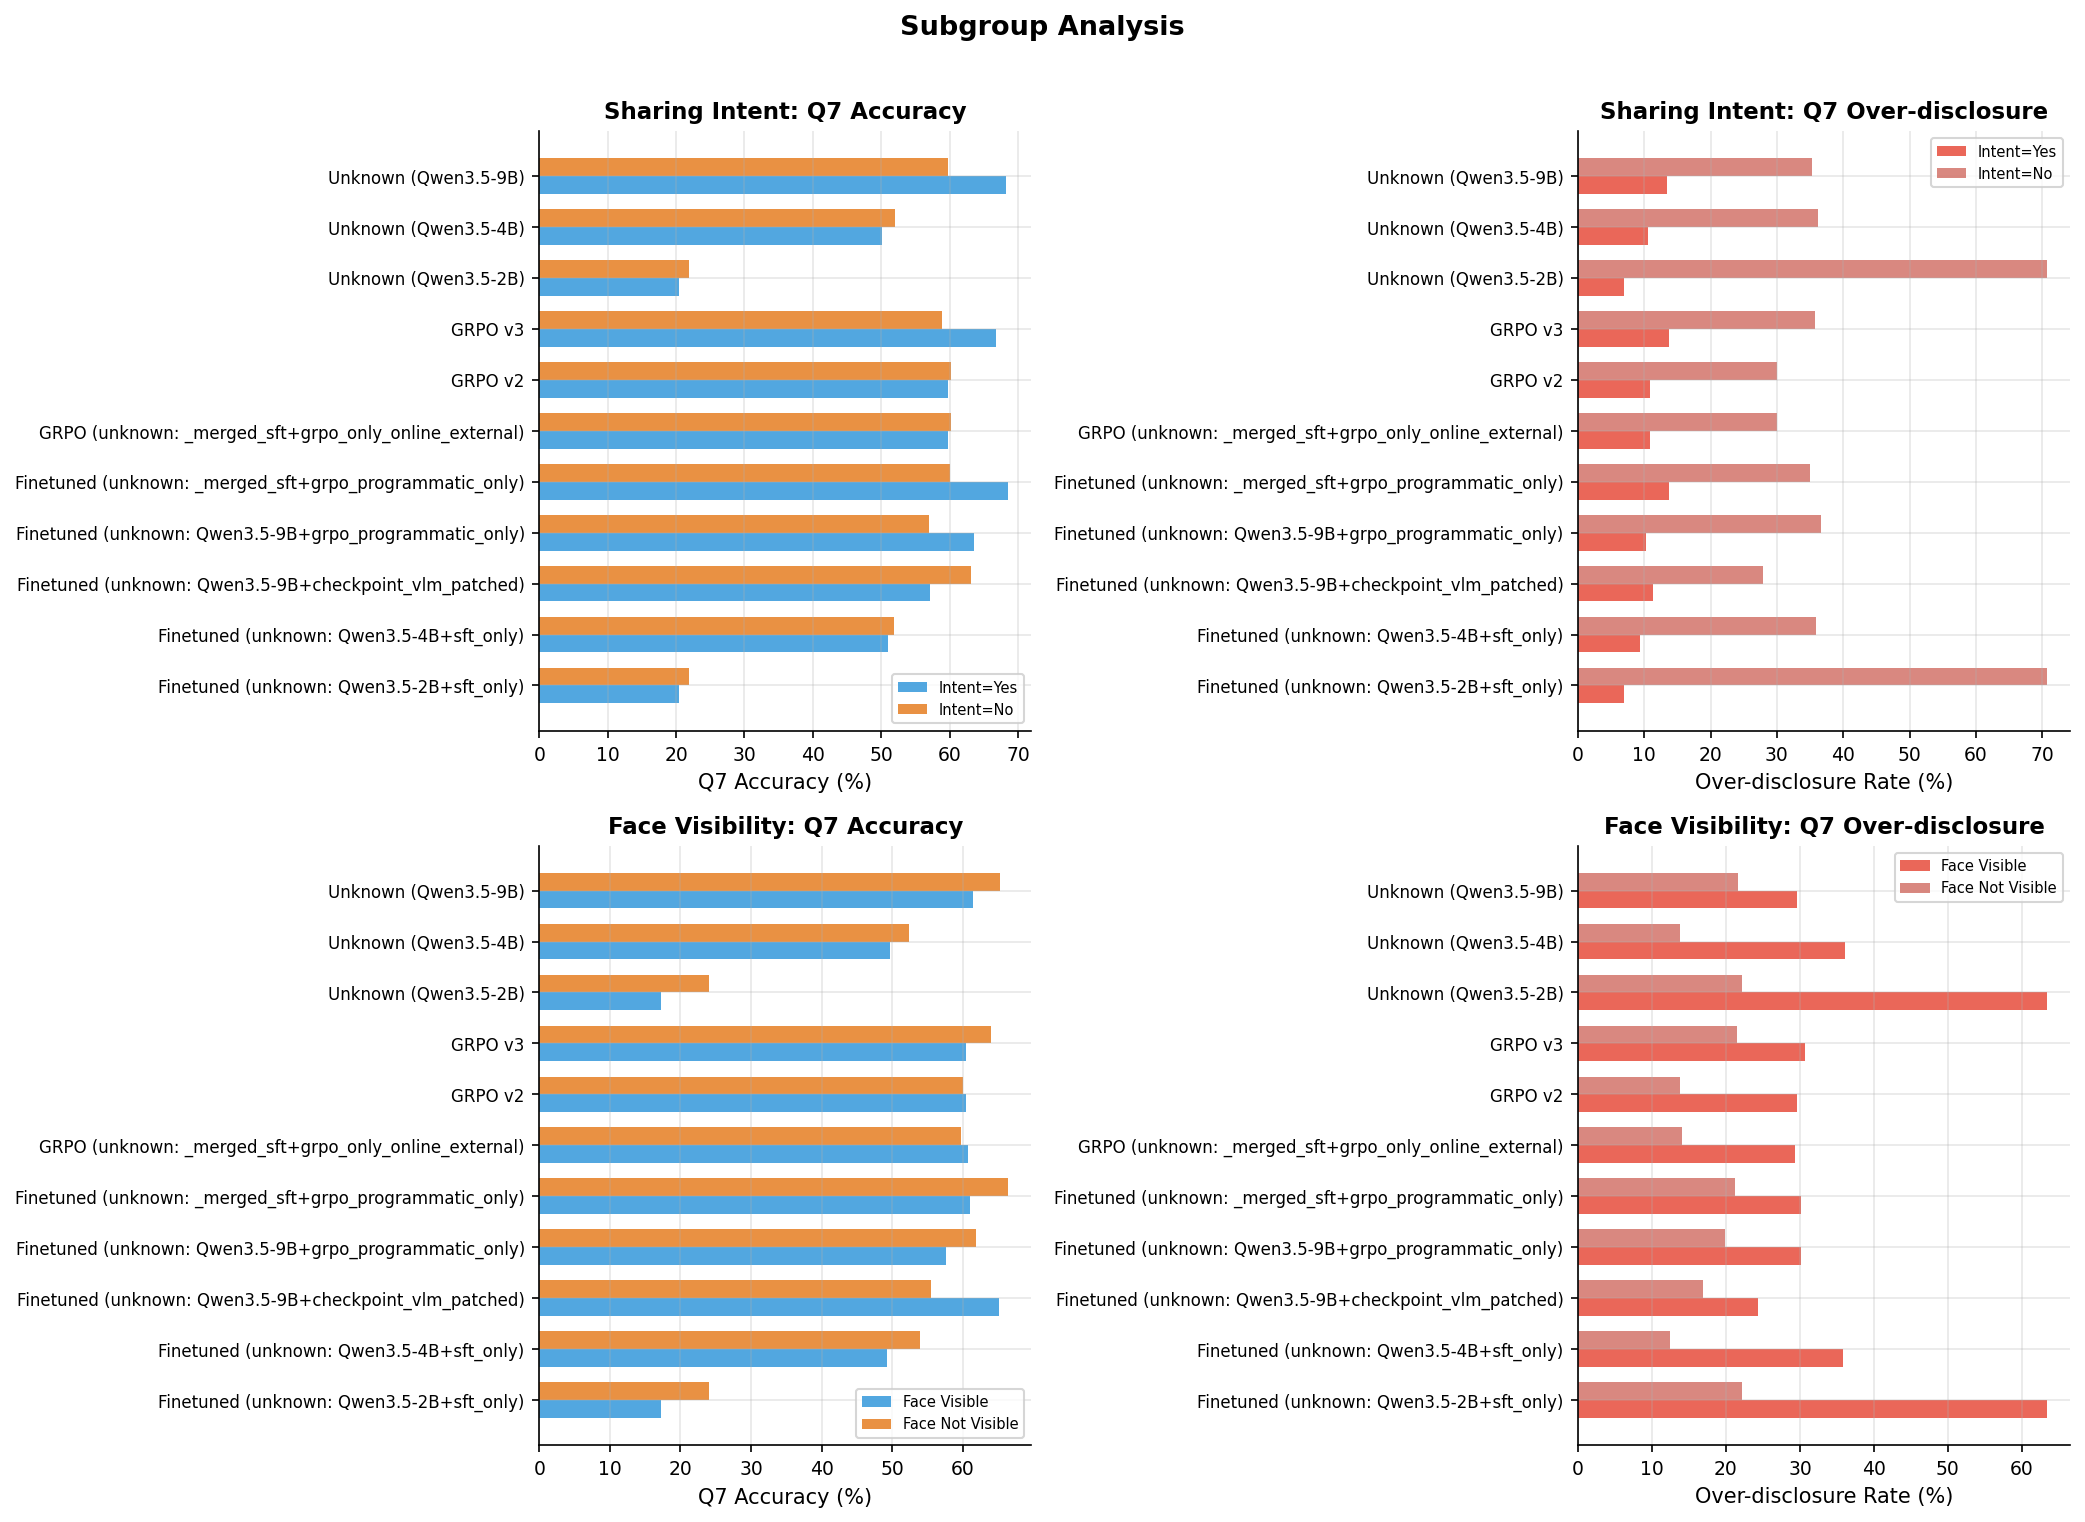

In [16]:
subgroup_pairs = [
    ("Sharing Intent",  "sharing_intent_yes", "sharing_intent_no",  "Intent=Yes", "Intent=No"),
    ("Face Visibility", "face_visible",        "face_not_visible",   "Face Visible", "Face Not Visible"),
]

fig, axes = plt.subplots(len(subgroup_pairs), 2, figsize=(14, 5 * len(subgroup_pairs)))
if len(subgroup_pairs) == 1:
    axes = axes[np.newaxis, :]

for row_idx, (title, sg_a, sg_b, label_a, label_b) in enumerate(subgroup_pairs):
    # Panel 1: Accuracy comparison
    ax = axes[row_idx, 0]
    acc_a = df[f"sg_{sg_a}_accuracy"].fillna(0).values * 100
    acc_b = df[f"sg_{sg_b}_accuracy"].fillna(0).values * 100
    x = np.arange(len(df))
    w = 0.35
    ax.barh(x - w/2, acc_a, w, label=label_a, color="#3498db", alpha=0.85)
    ax.barh(x + w/2, acc_b, w, label=label_b, color="#e67e22", alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(df["variant"], fontsize=8)
    ax.set_xlabel("Q7 Accuracy (%)")
    ax.set_title(f"{title}: Q7 Accuracy", fontweight="bold")
    ax.legend(fontsize=7)

    # Panel 2: Over-disclosure comparison
    ax2 = axes[row_idx, 1]
    over_a = df[f"sg_{sg_a}_over_disclosure_rate"].fillna(0).values * 100
    over_b = df[f"sg_{sg_b}_over_disclosure_rate"].fillna(0).values * 100
    ax2.barh(x - w/2, over_a, w, label=label_a, color="#e74c3c", alpha=0.85)
    ax2.barh(x + w/2, over_b, w, label=label_b, color="#c0392b", alpha=0.6)
    ax2.set_yticks(x)
    ax2.set_yticklabels(df["variant"], fontsize=8)
    ax2.set_xlabel("Over-disclosure Rate (%)")
    ax2.set_title(f"{title}: Q7 Over-disclosure", fontweight="bold")
    ax2.legend(fontsize=7)

plt.suptitle("Subgroup Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Training progression

Compare key metrics across training stages: Base → SFT → GRPO variants.
Visualize as a connected scatter / line plot to show progression.

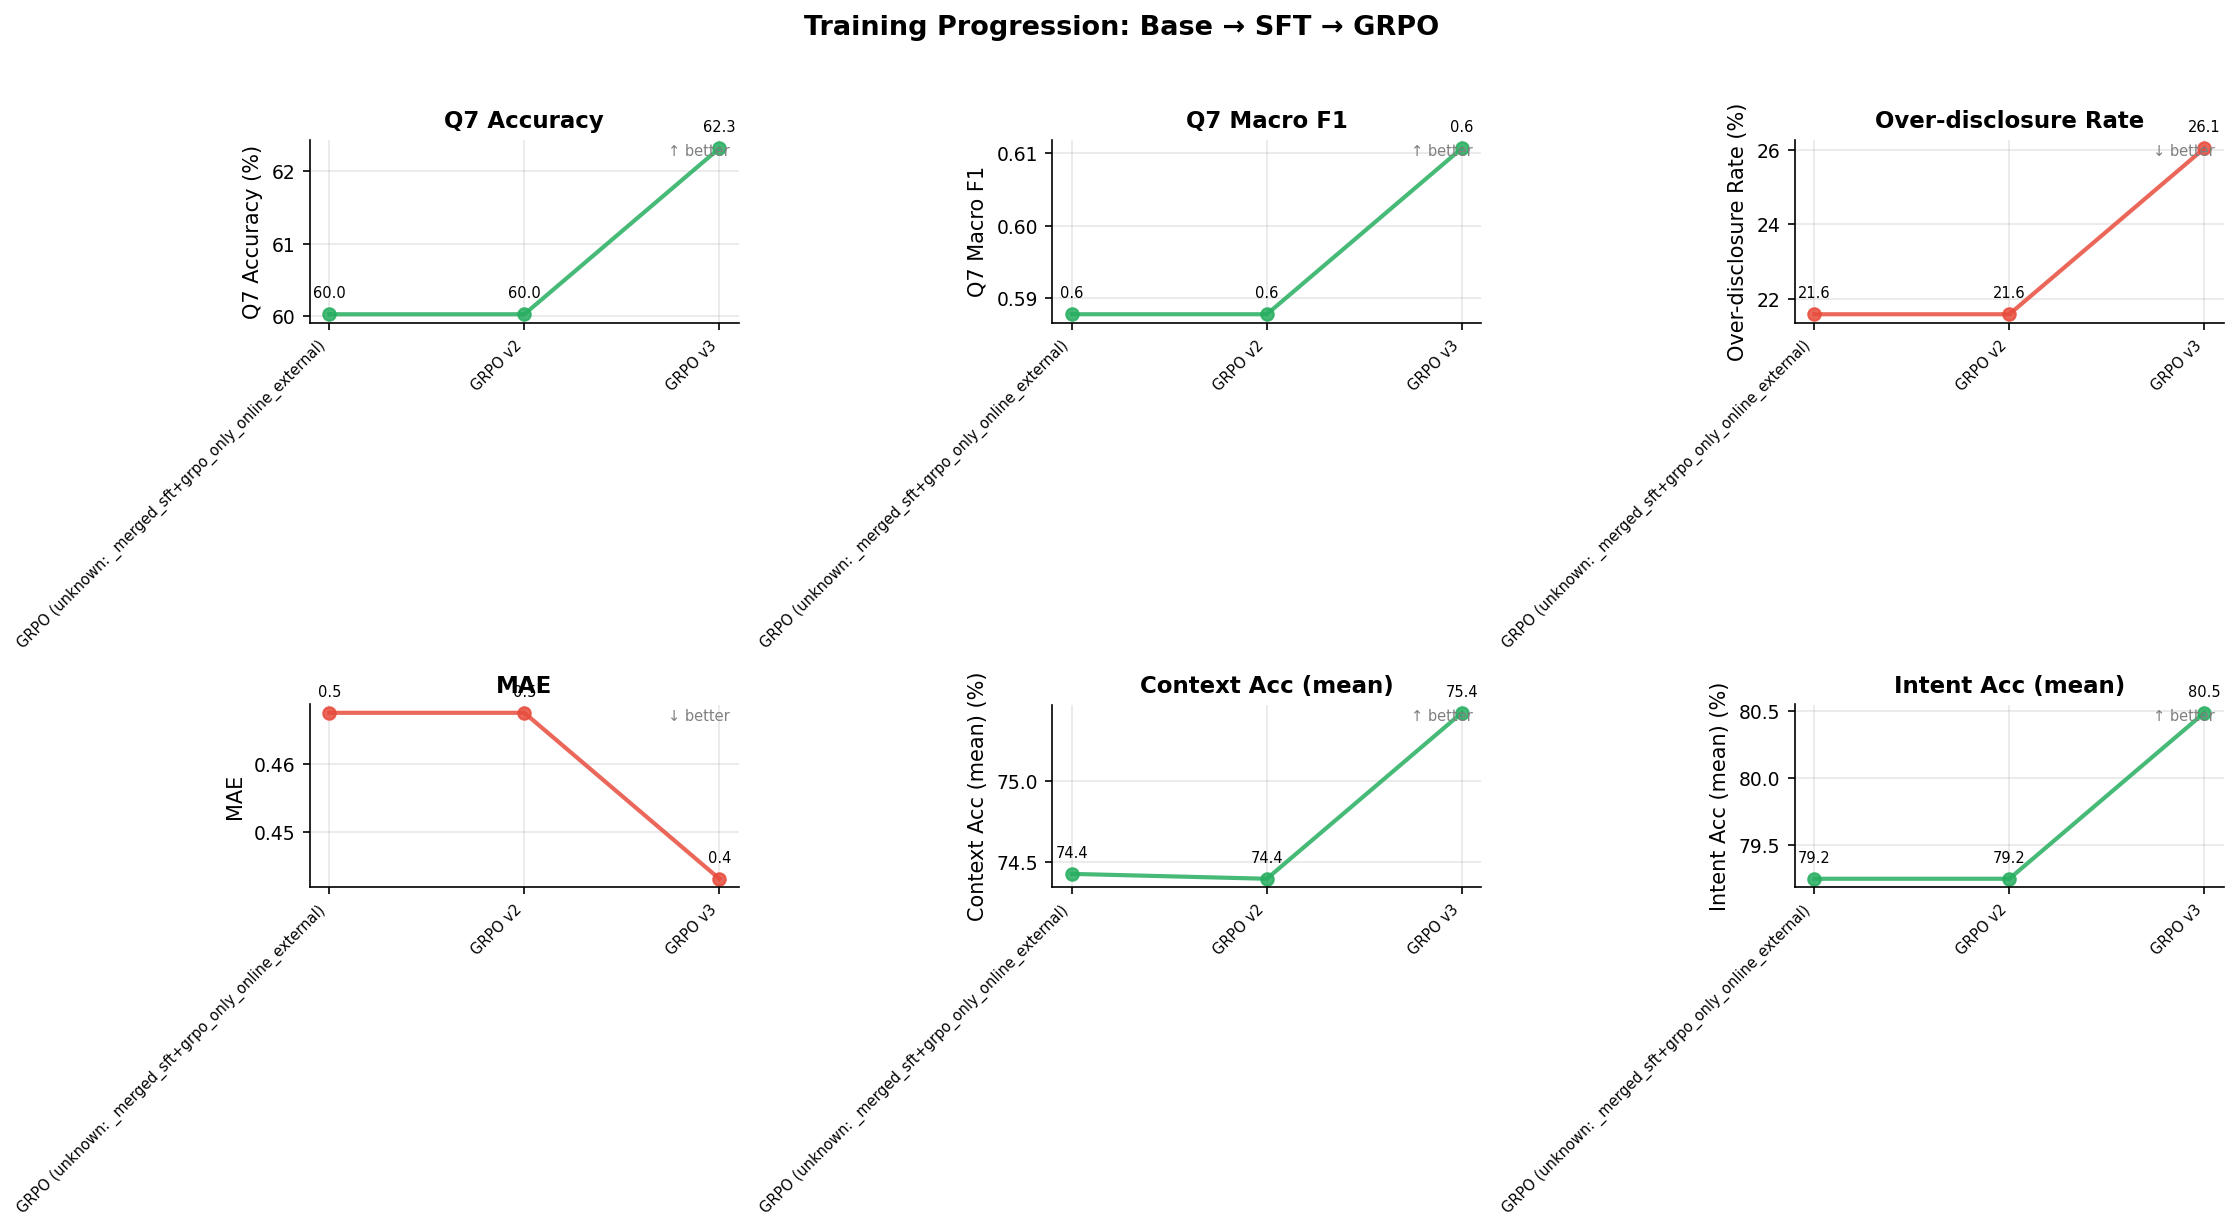

In [17]:
# ── Define training progression groups ─────────────────────────────────────
PROGRESSION_GROUPS = {
    "Training Stage": ["Base (zero-shot)", "SFT-CI"],  # extend with best GRPO
}
# Add all GRPO variants found to the progression
grpo_variants = [v for v in df["variant"] if v.startswith("GRPO")]
PROGRESSION_GROUPS["Training Stage"].extend(sorted(grpo_variants))

# Metrics to track
prog_metrics = [
    ("Q7_acc", "Q7 Accuracy", True),
    ("Q7_f1", "Q7 Macro F1", True),
    ("Q7_over_disclosure_rate", "Over-disclosure Rate", False),
    ("Q7_mae", "MAE", False),
    ("context_acc", "Context Acc (mean)", True),
    ("intent_acc", "Intent Acc (mean)", True),
]
# Filter to metrics with data
prog_metrics = [(col, label, hb) for col, label, hb in prog_metrics
                if col in df.columns and df[col].notna().any()]

if prog_metrics:
    ncols = min(3, len(prog_metrics))
    nrows = int(np.ceil(len(prog_metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

    for group_name, variant_order in PROGRESSION_GROUPS.items():
        present = [v for v in variant_order if v in df["variant"].values]
        if len(present) < 2:
            continue

        sub = df[df["variant"].isin(present)].set_index("variant").loc[present]

        for ax_idx, (col, label, higher_better) in enumerate(prog_metrics):
            ax = axes[ax_idx // ncols, ax_idx % ncols]
            vals = sub[col].values
            if col.endswith("_rate") or col.endswith("_acc") or col == "context_acc" or col == "intent_acc":
                vals = vals * 100  # to percentage
                ylabel = f"{label} (%)"
            else:
                ylabel = label

            x = range(len(present))
            color = "#27ae60" if higher_better else "#e74c3c"
            ax.plot(x, vals, "o-", color=color, markersize=6, linewidth=2, alpha=0.85)

            # Annotate points
            for xi, (v, val) in enumerate(zip(present, vals)):
                if not np.isnan(val):
                    ax.annotate(f"{val:.1f}", (xi, val), textcoords="offset points",
                                xytext=(0, 8), ha="center", fontsize=7)

            ax.set_xticks(list(x))
            ax.set_xticklabels(present, rotation=45, ha="right", fontsize=7)
            ax.set_ylabel(ylabel)
            ax.set_title(label, fontweight="bold")

            # Add arrow showing "better" direction
            direction = "↑ better" if higher_better else "↓ better"
            ax.annotate(direction, xy=(0.98, 0.98), xycoords="axes fraction",
                        ha="right", va="top", fontsize=7, color="gray")

    # Hide unused axes
    for idx in range(len(prog_metrics), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    fig.suptitle("Training Progression: Base \u2192 SFT \u2192 GRPO", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for progression plots.")

## 8. LaTeX export

Generate publication-ready booktabs table for the paper.

In [18]:
def vlm_results_to_latex(df: pd.DataFrame) -> str:
    """Generate a booktabs LaTeX table of VLM-GeoPrivacy results."""
    metric_spec = [
        ("context_acc",  "Context",  True),
        ("intent_acc",   "Intent",   True),
        ("Q7_acc",       "Q7 Acc",   True),
        ("Q7_f1",        "Q7 F1",    True),
        ("Q7_over_disclosure_rate",  "Over-disc.", False),
        ("Q7_under_disclosure_rate", "Under-disc.", False),
        ("Q7_mae",       "MAE",       False),
        ("Q7_abstention_violation_rate", "Abst.~Viol.", False),
    ]
    # Filter to columns with data
    metric_spec = [(col, hdr, hb) for col, hdr, hb in metric_spec
                   if col in df.columns and df[col].notna().any()]

    # Compute best values for bolding
    best = {}
    for col, _, hb in metric_spec:
        vals = df[col].dropna()
        if len(vals) > 0:
            best[col] = vals.max() if hb else vals.min()

    n_metrics = len(metric_spec)
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{VLM-GeoPrivacyBench results for Qwen3.5-9B variants (\%).}")
    lines.append(r"\label{tab:vlm-geoprivacy-qwen35}")
    lines.append(r"\resizebox{\linewidth}{!}{%")
    lines.append(r"\begin{tabular}{l" + "c" * n_metrics + r"}")
    lines.append(r"\toprule")

    # Header with arrows
    headers = []
    for _, hdr, hb in metric_spec:
        arrow = r"$\uparrow$" if hb else r"$\downarrow$"
        headers.append(f"{hdr} {arrow}")
    lines.append("Variant & " + " & ".join(headers) + r" \\")
    lines.append(r"\midrule")

    for _, row in df.iterrows():
        cells = [row["variant"].replace("_", r"\_")]
        for col, _, hb in metric_spec:
            val = row.get(col, np.nan)
            if pd.isna(val):
                cells.append("\u2014")
            else:
                # Convert to percentage for rate/accuracy columns
                if col != "Q7_mae" and col != "Q7_f1":
                    display_val = val * 100
                else:
                    display_val = val
                formatted = f"{display_val:.1f}"
                # Bold best
                if col in best and abs(val - best[col]) < 1e-6:
                    formatted = r"\textbf{" + formatted + "}"
                cells.append(formatted)
        lines.append(" & ".join(cells) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)


latex_str = vlm_results_to_latex(df)
print(latex_str)

\begin{table}[t]
\centering
\caption{VLM-GeoPrivacyBench results for Qwen3.5-9B variants (\%).}
\label{tab:vlm-geoprivacy-qwen35}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lcccccccc}
\toprule
Variant & Context $\uparrow$ & Intent $\uparrow$ & Q7 Acc $\uparrow$ & Q7 F1 $\uparrow$ & Over-disc. $\downarrow$ & Under-disc. $\downarrow$ & MAE $\downarrow$ & Abst.~Viol. $\downarrow$ \\
\midrule
Finetuned (unknown: Qwen3.5-2B+sft\_only) & 48.1 & 63.0 & 21.2 & 0.1 & 42.8 & 36.0 & 0.8 & 100.0 \\
Finetuned (unknown: Qwen3.5-4B+sft\_only) & 71.7 & 71.3 & 51.5 & 0.5 & 24.3 & 24.3 & 0.5 & 51.6 \\
Finetuned (unknown: Qwen3.5-9B+checkpoint\_vlm\_patched) & 73.4 & 80.1 & 60.5 & 0.6 & \textbf{20.7} & 18.8 & 0.5 & \textbf{38.5} \\
Finetuned (unknown: Qwen3.5-9B+grpo\_programmatic\_only) & 72.0 & 80.6 & 59.9 & 0.6 & 25.0 & 15.1 & 0.5 & 51.0 \\
Finetuned (unknown: \_merged\_sft+grpo\_programmatic\_only) & 74.9 & \textbf{81.7} & \textbf{63.7} & \textbf{0.6} & 25.7 & \textbf{10.6} & \textbf{0.4} & 46.0 \\


In [19]:
# ── Save outputs ───────────────────────────────────────────────────────────
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)
(out_dir / "vlm_geoprivacy_qwen35.tex").write_text(latex_str)
print(f"Saved LaTeX to {(out_dir / 'vlm_geoprivacy_qwen35.tex').resolve()}")

# Also save the raw comparison DataFrame
csv_path = out_dir / "vlm_geoprivacy_qwen35.csv"
df.to_csv(csv_path, index=False)
print(f"Saved CSV to {csv_path.resolve()}")

Saved LaTeX to /share/pierson/matt/UAIR/notebooks/COLM26/vlm_geoprivacy/tables/vlm_geoprivacy_qwen35.tex
Saved CSV to /share/pierson/matt/UAIR/notebooks/COLM26/vlm_geoprivacy/tables/vlm_geoprivacy_qwen35.csv


In [20]:
# ── Summary statistics ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

if "Base (zero-shot)" in df["variant"].values:
    base = df[df["variant"] == "Base (zero-shot)"].iloc[0]
    print(f"\nBaseline Q7 Acc: {base['Q7_acc']*100:.1f}%")
    print(f"Baseline Q7 F1:  {base['Q7_f1']:.3f}")

# Best GRPO variant
grpo_df = df[df["variant"].str.startswith("GRPO")]
if len(grpo_df) > 0:
    best_grpo = grpo_df.loc[grpo_df["Q7_acc"].idxmax()]
    print(f"\nBest GRPO variant: {best_grpo['variant']}")
    print(f"  Q7 Acc: {best_grpo['Q7_acc']*100:.1f}%")
    print(f"  Q7 F1:  {best_grpo['Q7_f1']:.3f}")
    print(f"  Over-disclosure: {best_grpo['Q7_over_disclosure_rate']*100:.1f}%")
    print(f"  MAE: {best_grpo['Q7_mae']:.3f}")

    if "Base (zero-shot)" in df["variant"].values:
        delta_acc = (best_grpo["Q7_acc"] - base["Q7_acc"]) * 100
        delta_over = (best_grpo["Q7_over_disclosure_rate"] - base["Q7_over_disclosure_rate"]) * 100
        print(f"\n  Delta vs base:")
        print(f"    Q7 Acc: {'+' if delta_acc >= 0 else ''}{delta_acc:.1f} pp")
        print(f"    Over-disc: {'+' if delta_over >= 0 else ''}{delta_over:.1f} pp")


SUMMARY

Best GRPO variant: GRPO v3
  Q7 Acc: 62.3%
  Q7 F1:  0.611
  Over-disclosure: 26.1%
  MAE: 0.443
